In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")
print(merged.shape)
merged.head()

(66666, 54)


,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,NORAD_CAT_ID,BSTAR,MEAN_MOTION_DOT,SEMIMAJOR_AXIS,PERIOD,...,rx_km,ry_km,rz_km,vx_km_s,vy_km_s,vz_km_s,tle_age_days,altitude_km,speed_km_s,regime
0,OPS 3674 (VELA 4),2026-03-22T04:38:47.037408,0.23985689,0.57463450,48.7444,837,0.00000000000000,0.00000156,109420.923,6003.580,...,-87842.248216,66031.086790,40166.139083,-1.098975,-0.450464,1.326665,-4.0,110631.921857,1.780647,GEO
1,YZ-1 R/B,2026-03-22T00:05:53.344896,0.27910401,0.68547050,12.1133,41929,0.00000000000000,-0.00000606,98906.414,5159.367,...,-71978.947246,26862.548852,13005.642656,-2.142409,-1.165972,0.501345,-4.0,71550.191715,2.490131,GEO
2,ASTRON,2026-03-21T10:33:08.348544,0.24283977,0.65788428,78.4402,13901,0.00000000000000,0.00000203,108523.045,5929.836,...,-56540.136904,-127218.270086,-93797.684633,0.275027,0.036663,-0.999533,-3.0,161495.854880,1.037328,GEO
3,OPS 3662 (VELA 3),2026-03-20T19:37:22.087200,0.23902374,0.49573576,52.5257,836,0.00000000000000,0.00000640,109675.043,6024.506,...,-69574.444483,-75544.686826,128140.723117,0.671024,-0.859229,-0.177731,-3.0,157847.293602,1.104598,GEO
4,CXO,2026-03-20T11:08:23.080992,0.37808217,0.79854940,54.7244,25867,0.00000000000000,0.00001048,80787.538,3808.696,...,-25178.252625,-94524.345224,96227.317779,0.448764,-0.820913,0.023654,-2.0,130845.955703,0.935867,GEO


In [12]:
merged['DECAY_EPOCH'] = pd.to_datetime(merged['DECAY_EPOCH'], errors='coerce')
merged['LAUNCH_DATE'] = pd.to_datetime(merged['LAUNCH_DATE'], errors='coerce')

# how many objects actually have decay predictions
print("objects with decay epoch:", merged['DECAY_EPOCH'].notna().sum())
print("total objects:", len(merged))

objects with decay epoch: 34184
total objects: 66666


In [13]:
# instead of predicting exact days (only 77 objects)
# lets predict decay risk category for all 66k objects
# using physics — low perigee + high bstar = decaying fast

merged['BSTAR'] = pd.to_numeric(merged['BSTAR'], errors='coerce')
merged['PERIGEE'] = pd.to_numeric(merged['PERIGEE'], errors='coerce')

def decay_risk(row):
    if row['PERIGEE'] < 300 and abs(row['BSTAR']) > 0.0001:
        return 'IMMINENT'   # decaying within months
    elif row['PERIGEE'] < 500 and abs(row['BSTAR']) > 0.00001:
        return 'ELEVATED'   # decaying within years
    elif row['PERIGEE'] < 800:
        return 'MODERATE'   # LEO, will decay eventually
    else:
        return 'STABLE'     # GEO/MEO, basically forever

merged['decay_risk'] = merged.apply(decay_risk, axis=1)
print(merged['decay_risk'].value_counts())

decay_risk
MODERATE    20549
IMMINENT    19517
ELEVATED    13756
STABLE      12844
Name: count, dtype: int64


In [18]:
features = [
    'ECCENTRICITY', 'INCLINATION', 'MEAN_MOTION',
    'MEAN_MOTION_DOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE',
    'altitude_km', 'speed_km_s', 'attr_mass',
    'attr_xSectAvg', 'RCSVALUE', 'tle_age_days'
]

features = [f for f in features if f in merged.columns]
X = merged[features].apply(pd.to_numeric, errors='coerce').fillna(0)
y = merged['decay_risk']

print("X shape:", X.shape)

X shape: (66666, 13)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

    ELEVATED       0.95      0.91      0.93      2751
    IMMINENT       0.92      0.95      0.93      3904
    MODERATE       0.93      0.93      0.93      4110
      STABLE       0.99      0.98      0.98      2569

    accuracy                           0.94     13334
   macro avg       0.95      0.94      0.94     13334
weighted avg       0.94      0.94      0.94     13334



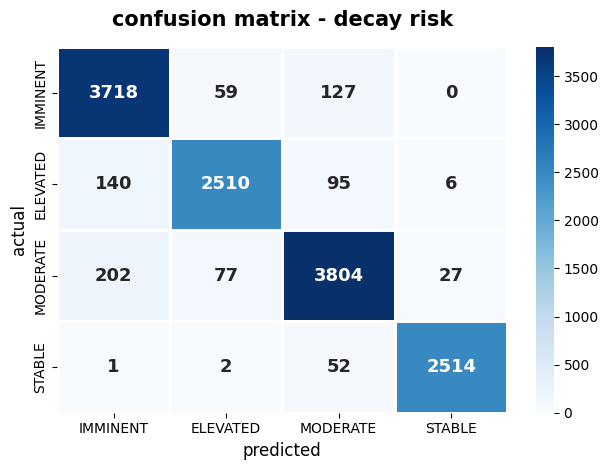

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'],
            yticklabels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title('confusion matrix - decay risk', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('actual', fontsize=12)
plt.xlabel('predicted', fontsize=12)
plt.tight_layout()
plt.show()

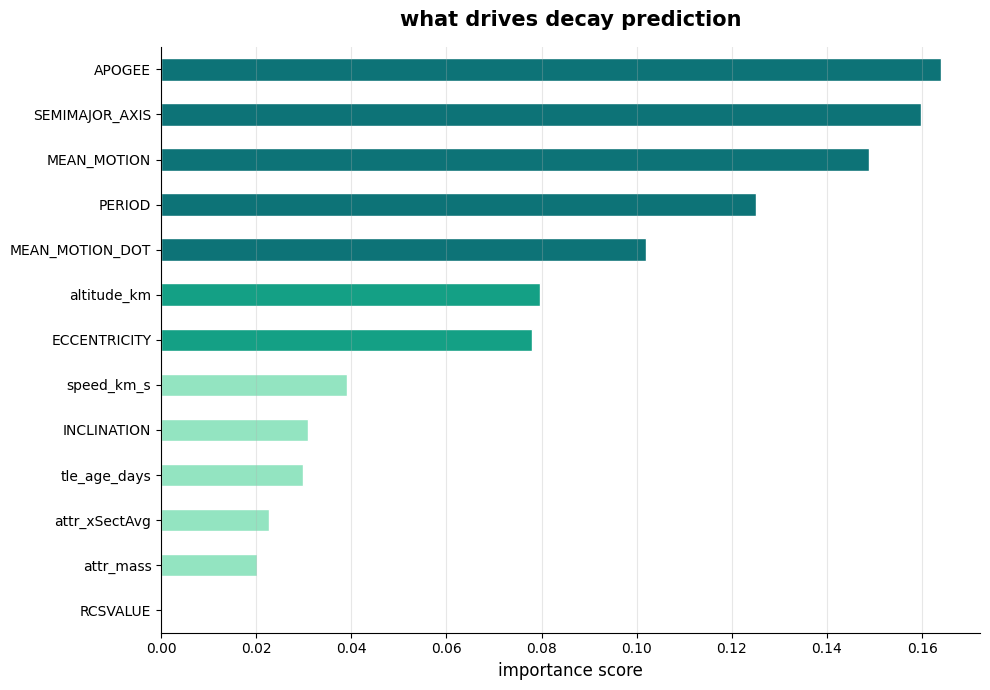

In [24]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#0d7377' if v > 0.10 else '#14a085' if v > 0.05 else '#93e4c1' for v in importance.values]
importance.plot(kind='barh', color=colors, edgecolor='white', ax=ax)

plt.title('what drives decay prediction', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('importance score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()